# PHONEMeS

The signaling method `PHONEMeS` identifies a directed, acyclic subnetwork that connects known perturbation targets to phosphosites supported by an experiment. Typical inputs are a directed prior-knowledge network (PKN), one or more perturbed proteins, and a score for each measured phosphosite.

CORNETO expects differential-analysis results and a PKN to be prepared beforehand. It provides `compute_phonemes_scores` for converting p-values and fold changes into PHONEMeS scores, but it does not perform differential analysis, map phosphosites to proteins, or construct the PKN.

## Choosing the appropriate PHONEMeS workflow

| Workflow | Starting proteins | Question answered |
| --- | --- | --- |
| `PHONEMeS` | Known experimental perturbations, such as drug targets or inhibited kinases | Which downstream interactions connect the perturbations to the phosphoproteomic measurements? |
| `BidirectionalPHONEMeS` | Kinases inferred to be regulated from the data | Which upstream and downstream interactions jointly explain the measurements around those kinases? |
| Original upside-down PHONEMeS | Kinases inferred to be regulated from the data | Which separate upstream and downstream networks are found before taking their post-hoc union? |

Use ordinary `PHONEMeS` when the experiment provides a known causal starting point. Its `perturbations` are mandatory roots, and inferred interactions follow the PKN downstream toward measured phosphosites.

Use [`BidirectionalPHONEMeS`](bidirectional-phonemes.ipynb) when kinase-activity analysis provides regulated kinases rather than known perturbations. CORNETO then optimizes the upstream and downstream explanations jointly.

In [1]:
import numpy as np
import pandas as pd

from corneto import Graph
from corneto.methods import PHONEMeS, compute_phonemes_scores

## Understanding phosphosite scores

PHONEMeS minimizes its objective, so score signs have the following meaning:

| Score | Effect on the inferred network |
| --- | --- |
| Negative | Rewards inclusion of the phosphosite |
| Positive | Penalizes inclusion of the phosphosite |
| Zero | Marks the phosphosite as measured without favoring or penalizing it |

The magnitude controls the strength of the preference. These signs are **optimization preferences**, not activity labels. A negative score does not itself mean that a site is activated, and a positive score does not mean that it is inhibited.

Every key identifies a measured phosphosite, including keys with value `0.0`. A positively scored site may still appear when it is needed as an intermediate in a better overall explanation.

## Computing scores from differential results

`compute_phonemes_scores` starts from

$$
r_v = \log_2\left(\frac{p_v}{p_{\mathrm{threshold}}}\right).
$$

Sites satisfying the selected evidence criteria receive $-|r_v|$, rewarding inclusion. Other measured sites receive $+|r_v|$, penalizing inclusion. By default, positive and negative scores are scaled separately to $[0,1]$ and $[-1,0]$.

In [2]:
scores = compute_phonemes_scores(
    {
        "ERK1_S123": 0.001,
        "AKT1_S473": 0.20,
    },
    fold_changes={
        "ERK1_S123": 2.1,
        "AKT1_S473": 0.3,
    },
    pvalue_threshold=0.05,
    fold_change_threshold=1.0,
    direction="both",
)
scores

{'ERK1_S123': -1.0, 'AKT1_S473': 1.0}

## Inferring a network for one condition

The toy PKN below contains two routes from the known perturbation `EGFR` to the supported site `ERK1_S123`, one route to the penalized site `AKT1_S473`, and a disconnected interaction. The disconnected region cannot explain a measurement and will be removed during preprocessing.

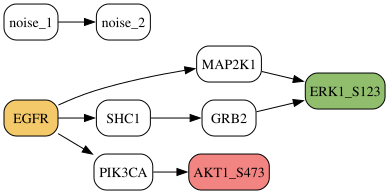

In [3]:
pkn_edges = [
    ("EGFR", "MAP2K1"),
    ("MAP2K1", "ERK1_S123"),
    ("EGFR", "SHC1"),
    ("SHC1", "GRB2"),
    ("GRB2", "ERK1_S123"),
    ("EGFR", "PIK3CA"),
    ("PIK3CA", "AKT1_S473"),
    ("noise_1", "noise_2"),
]

pkn = Graph()
pkn.add_edges(pkn_edges)

pkn.plot(
    graph_attr={"rankdir": "LR"},
    node_attr={
        "fixedsize": "false",
        "shape": "box",
        "style": "rounded",
        "margin": "0.08,0.04",
    },
    custom_vertex_attr={
        "EGFR": {"fillcolor": "#f3c969", "style": "rounded,filled"},
        "ERK1_S123": {"fillcolor": "#90be6d", "style": "rounded,filled"},
        "AKT1_S473": {"fillcolor": "#f28482", "style": "rounded,filled"},
    }
)

Interaction costs control which explanation is preferred. Here, the two-edge route through `MAP2K1` costs `0.8`, whereas the three-edge route through `SHC1` and `GRB2` costs `0.3`. The supported phosphosite has score `-1.0`, so the cheaper route remains worthwhile.

In [4]:
edge_costs = {
    0: 0.4,
    1: 0.4,
    2: 0.1,
    3: 0.1,
    4: 0.1,
    5: 0.1,
    6: 0.1,
}

method = PHONEMeS()
problem = method.build(
    pkn,
    perturbations=["EGFR"],
    phosphosite_scores=scores,
    edge_costs=edge_costs,
)
problem.solve(solver="scipy")

Problem(Minimize(Expression(AFFINE, UNKNOWN, ())), [Inequality(Constant(CONSTANT, NONNEGATIVE, (10, 1))), Inequality(Variable((10, 1), _flow)), Inequality(Constant(CONSTANT, ZERO, (7, 1))), Inequality(Variable((7, 1), _dag_layer)), Equality(Expression(AFFINE, UNKNOWN, (7, 1)), Constant(CONSTANT, ZERO, ())), Inequality(Expression(AFFINE, NONNEGATIVE, (10, 1))), Equality(Expression(AFFINE, ZERO, (10, 1)), Constant(CONSTANT, ZERO, ())), Equality(Expression(AFFINE, NONNEGATIVE, (10, 1)), Constant(CONSTANT, ZERO, ())), Inequality(Expression(AFFINE, NONNEGATIVE, (10, 1))), Inequality(Variable((10, 1), _flow)), Inequality(Expression(AFFINE, UNKNOWN, (7, 1))), Inequality(Expression(AFFINE, UNKNOWN, (7, 1))), Inequality(Expression(AFFINE, UNKNOWN, (7, 1))), Inequality(Expression(AFFINE, UNKNOWN, (7, 1))), Inequality(Expression(AFFINE, NONNEGATIVE, (7, 1))), Inequality(Expression(AFFINE, NONNEGATIVE, (7, 1))), Inequality(Constant(CONSTANT, NONNEGATIVE, (7, 1))), Inequality(Expression(AFFINE, NON

## Reading and plotting the inferred subnetwork

`edge_selected` and `vertex_selected` are binary solution arrays with one column per condition. Their rows follow the retained biological interactions and vertices in `method.processed_graph`.

In [5]:
selected_edges = problem.expr.edge_selected.value[:, 0] > 0.5
selected_vertices = problem.expr.vertex_selected.value[:, 0] > 0.5

selected_edge_indices = np.flatnonzero(selected_edges)
selected_vertex_names = np.asarray(
    method.processed_graph.V,
    dtype=object,
)[selected_vertices]
inferred_network = method.processed_graph.edge_subgraph(selected_edge_indices)

selected_interactions = [
    (next(iter(source)), next(iter(target)))
    for source, target in inferred_network.E
]
print("Selected vertices:", selected_vertex_names.tolist())
print("Selected interactions:", selected_interactions)

Selected vertices: ['EGFR', 'ERK1_S123', 'SHC1', 'GRB2']
Selected interactions: [('EGFR', 'SHC1'), ('SHC1', 'GRB2'), ('GRB2', 'ERK1_S123')]


The inferred network selects the supported ERK site through the less expensive route. It does not include the penalized AKT site or the disconnected interaction.

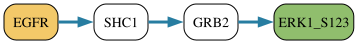

In [6]:
inferred_network.plot(
    graph_attr={"rankdir": "LR"},
    node_attr={
        "fixedsize": "false",
        "shape": "box",
        "style": "rounded",
        "margin": "0.08,0.04",
    },
    custom_edge_attr={
        edge: {"color": "#277da1", "penwidth": "3"}
        for edge in range(inferred_network.num_edges)
    },
    custom_vertex_attr={
        "EGFR": {"fillcolor": "#f3c969", "style": "rounded,filled"},
        "ERK1_S123": {"fillcolor": "#90be6d", "style": "rounded,filled"},
    },
)

## Controlling network size with edge costs

Unspecified interactions use `default_edge_cost`, which defaults to `1e-5`. Positive costs favor smaller subnetworks. Larger costs require stronger negative phosphosite scores to justify additional interactions, so score and edge-cost scales should be chosen together.

`edge_costs` maps zero-based indices in `pkn.E` to costs. Negative costs are accepted and reward inclusion of an interaction, but should be used deliberately because they can add valid interactions that are not required to explain a negatively scored phosphosite.

Before optimization, CORNETO removes interactions that cannot lie on a directed path from a perturbation to a measured phosphosite. Unreachable measurements are omitted from `method.processed_data`; a perturbation that cannot reach any measured site is reported as an input error.

## Comparing multiple conditions

`compute_phonemes_scores` handles one or many conditions through the same function. A pandas DataFrame uses phosphosites as rows and conditions as columns. Pandas is optional for CORNETO users, but convenient in typical phosphoproteomics workflows.

In [7]:
pvalues = pd.DataFrame(
    {
        "control": {"ERK1_S123": 0.001, "AKT1_S473": 0.20},
        "treated": {"ERK1_S123": 0.20, "AKT1_S473": 0.002},
    }
)
fold_changes = pd.DataFrame(
    {
        "control": {"ERK1_S123": 2.1, "AKT1_S473": 0.3},
        "treated": {"ERK1_S123": 0.2, "AKT1_S473": 1.8},
    }
)

score_table = compute_phonemes_scores(
    pvalues,
    fold_changes=fold_changes,
    pvalue_threshold=0.05,
    fold_change_threshold=1.0,
    direction="both",
)
score_table

,control,treated
ERK1_S123,-1.0,1.0
AKT1_S473,1.0,-1.0


Pass the DataFrame directly to `build_many`, together with a named perturbation mapping. Condition names must match.

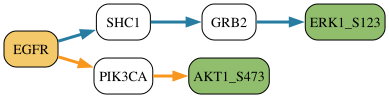

In [8]:
many_method = PHONEMeS()
many_problem = many_method.build_many(
    pkn,
    perturbations={
        "control": ["EGFR"],
        "treated": ["EGFR"],
    },
    phosphosite_scores=score_table,
    edge_costs=edge_costs,
)
many_problem.solve(solver="scipy")

control = many_problem.expr.edge_selected.value[:, 0] > 0.5
treated = many_problem.expr.edge_selected.value[:, 1] > 0.5
combined = many_problem.expr.edge_selected_any.value > 0.5

combined_indices = np.flatnonzero(combined)
combined_network = many_method.processed_graph.edge_subgraph(combined_indices)
edge_style = {}
for displayed_index, original_index in enumerate(combined_indices):
    if control[original_index] and treated[original_index]:
        color = "#7b2cbf"
    elif control[original_index]:
        color = "#277da1"
    else:
        color = "#f8961e"
    edge_style[displayed_index] = {"color": color, "penwidth": "3"}

combined_network.plot(
    graph_attr={"rankdir": "LR"},
    node_attr={
        "fixedsize": "false",
        "shape": "box",
        "style": "rounded",
        "margin": "0.08,0.04",
    },
    custom_edge_attr=edge_style,
    custom_vertex_attr={
        "EGFR": {"fillcolor": "#f3c969", "style": "rounded,filled"},
        "ERK1_S123": {"fillcolor": "#90be6d", "style": "rounded,filled"},
        "AKT1_S473": {"fillcolor": "#90be6d", "style": "rounded,filled"},
    },
)

Blue interactions are used in `control`, orange interactions in `treated`, and purple interactions would be shared.

Each condition has its own phosphosite scores and inferred subnetwork, but PHONEMeS penalizes the size of their **combined network**. An interaction used in several conditions contributes its cost once, not once per condition. This encourages reuse of a common signaling backbone without requiring condition networks to be identical.

Consequently, `edge_costs` defines one global cost per PKN interaction. It cannot assign different costs to the same interaction in different conditions.

## Advanced: implementation in CORNETO

This section explains how CORNETO represents the biological problem. It is not needed for routine analysis.

For retained PKN edges, let $Z_{ec}$ indicate whether edge $e$ is selected in condition $c$, and let $X_{vc}$ indicate whether vertex $v$ is selected. CORNETO minimizes

$$
\sum_{v,c} s_{vc}X_{vc} + \sum_e c_eY_e,
\qquad Y_e = \bigvee_c Z_{ec}.
$$

Here, $s_{vc}$ is the phosphosite score, $c_e$ is the interaction cost, and $Y_e$ records whether an interaction is used by at least one condition.

CORNETO implements connectivity with a nonnegative conserved flow. Condition-specific boundary interactions inject flow at perturbation targets and extract it at measured phosphosites. These are mathematical devices: they are not PKN interactions and do not appear in `edge_selected`, `edge_selected_any`, or the edge-cost term.

Sparse incidence matrices connect selected interactions to their endpoint vertices. Layer variables exclude directed cycles while allowing convergent signaling, so an inferred node may have more than one parent. Constraints are constructed as vectorized matrix expressions.

### Internal solution variables

| Expression | Meaning |
| --- | --- |
| `problem.expr.edge_selected` | Retained PKN interactions selected per condition |
| `problem.expr.vertex_selected` | Retained PKN vertices selected per condition |
| `problem.expr.edge_selected_any` | Union of selected retained interactions |
| `problem.expr.flow` | Internal connectivity values on PKN and boundary interactions |
| `problem.expr.dag_layer` | Internal acyclicity layer for each vertex |

Most analyses only need `edge_selected` and `vertex_selected`. Flow and layer values encode feasibility of the optimization model and should not be interpreted as biological measurements or signaling strength.

Several subnetworks may have the same optimum, so different solvers or solver settings can return different but equally good interaction sets.

### Advanced `Data` interface

Most users should use `build` or `build_many`. Use `build_from_data` when inputs already exist as CORNETO features:

```python
from corneto import Data

data = Data.from_dict(
    {
        "treated": {
            "features": [
                {"id": "EGFR", "mapping": "vertex", "role": "perturbation"},
                {
                    "id": "ERK1_S123",
                    "mapping": "vertex",
                    "role": "phosphosite",
                    "value": -2.4,
                },
                {"id": 3, "mapping": "edge", "value": 0.01},
            ]
        }
    }
)

advanced_problem = PHONEMeS().build_from_data(pkn, data)
```

A vertex that is both perturbed and measured uses role `"perturbation_phosphosite"`. Repeated edge-cost features in multiple samples must agree because the model defines one global cost for each PKN interaction.

### Reference-data validation

The CORNETO test suite includes a compact conversion of the MTOR inhibition example from `inst/PHONEMeS_example/Cluster/data4cluster_3.RData` in the original PHONEMeS-ILP repository. It contains a prepared 229-edge PKN, the `MTOR_HUMAN` perturbation, and 17 phosphosite scores. Tests compare the objective at solver-appropriate precision and verify reachability with both supported backends.

This implementation covers score construction, exact connectivity pruning, and the optimization core. Differential analysis, PKN construction, downsampling, and solver-specific solution pools remain separate workflows. See the original [PHONEMeS publication](https://doi.org/10.1038/ncomms9033) and [reference implementation](https://github.com/saezlab/PHONEMeS-ILP).